# 25. HAC-LSTM: Hierarchical Agglomerative Clustering + LSTM for Spectrum Prediction

Implements the **HAC-LSTM** method from:
**"Hierarchical Agglomerative Clustering and LSTM-based Load Prediction for Dynamic Spectrum Allocation"** (IEEE CCNC 2021).

## Paper (adapted to 72h→24h)
- **SRCC:** Spearman rank correlation between channel series; distance for clustering = 1 − |r_s|.
- **HAC:** Hierarchical agglomerative clustering with **complete linkage** (distance between clusters = max of pairwise distances). Correlated series are grouped; each cluster is predicted by its own LSTM so uncorrelated series do not interfere.
- **Low-pass filter:** Preprocess data to remove high-frequency noise (paper: cutoff 0.5) before clustering and prediction.
- **Per-cluster LSTM:** One LSTM per cluster; inputs/outputs are the channels in that cluster; final prediction is reassembled over channels.

## Same setup as 10–24
Data: work_dir/final, 72h→24h. Metrics: MAE, RMSE, MASE. Naive baseline. Same visuals.

**Why naive MAE can differ across notebooks:** MAE is computed the same way everywhere (`mean_absolute_error(y_test, y_pred_naive)` in 0–100% scale; naive = last value of lookback repeated). This notebook uses **one test sample per 24h block** in the fixed test period (e.g. 3 samples → 3 blocks). Others (e.g. 15, 17) build **many rolling test windows** (e.g. 1887). With only a few test windows, naive MAE can be higher (~12) if those windows are volatile; with many windows the average is more typical (~4).


**GPU:** Use kernel **Python 3.11 (cablelabs-3 .venv)** (Kernel → Change kernel) so TensorFlow uses the project's venv with tensorflow-metal.

In [27]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
print(f'TensorFlow: {tf.__version__}')


TensorFlow: 2.18.1


In [28]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_visible_devices(gpus, 'GPU')
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'GPU enabled: {len(gpus)} device(s)')
        with tf.device('/GPU:0'): _ = tf.constant(1)
        print('GPU ready.')
    except RuntimeError as e: print('GPU config:', e)
else: print('No GPU found. Change kernel to "Python 3.11 (cablelabs-3 .venv)" (Kernel → Change kernel), then re-run from the top.')
USE_GPU = len(gpus) > 0


GPU enabled: 1 device(s)
GPU ready.


## Data loading: multi-channel aligned (same as notebook 24)

In [29]:
work_dir = Path("work_dir")
if not work_dir.exists():
    work_dir = Path("../work_dir")
final_dir = work_dir / "final"
training_dir = final_dir / "training"
testing_dir = final_dir / "testing"
if not final_dir.exists() or not training_dir.exists() or not testing_dir.exists():
    raise FileNotFoundError("work_dir/final/training and testing not found")
class_options = sorted([d.name for d in training_dir.iterdir() if d.is_dir()])
LOOKBACK = 72
FORECAST_HORIZON = 24

def load_data_for_band(band_name: str, split: str):
    split_dir = final_dir / split / band_name
    if not split_dir.exists(): return pd.DataFrame()
    dfs = []
    for p in sorted(split_dir.glob("final_*.parquet")):
        try: dfs.append(pd.read_parquet(p))
        except Exception as e: print(f"Error loading {p}: {e}")
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

def build_multichannel_sequences(train_dfs, test_dfs, bands, lookback=72, horizon=24):
    merged_tr = None
    for band in bands:
        df = train_dfs[band]
        if df.empty: continue
        df = df.sort_values(["date", "hour"]).drop_duplicates(["date", "hour"])
        ths = sorted(df["threshold_dbm"].unique())
        if len(ths) > 1: df = df[df["threshold_dbm"] == ths[0]]
        au = df.groupby(["date", "hour"])["au_pct"].mean().reset_index().rename(columns={"au_pct": band})
        merged_tr = au if merged_tr is None else pd.merge(merged_tr, au, on=["date", "hour"], how="inner")
    if merged_tr is None or len(merged_tr) < lookback + horizon:
        return None, None, None, None, []
    band_cols = [b for b in bands if b in merged_tr.columns]
    N = len(band_cols)
    mat_tr = merged_tr[band_cols].values.astype(np.float32)
    merged_te = None
    for band in bands:
        df = test_dfs[band]
        if df.empty: continue
        df = df.sort_values(["date", "hour"])
        ths = sorted(df["threshold_dbm"].unique())
        if len(ths) > 1: df = df[df["threshold_dbm"] == ths[0]]
        au = df.groupby(["date", "hour"])["au_pct"].mean().reset_index().rename(columns={"au_pct": band})
        merged_te = au if merged_te is None else pd.merge(merged_te, au, on=["date", "hour"], how="inner")
    for c in band_cols:
        if c not in merged_te.columns: merged_te[c] = np.nan
    merged_te = merged_te[band_cols].ffill().fillna(0)
    mat_te = merged_te.values.astype(np.float32) if len(merged_te) > 0 else np.zeros((0, N))
    X_tr, y_tr = [], []
    for i in range(len(mat_tr) - lookback - horizon + 1):
        X_tr.append(mat_tr[i:i+lookback])
        y_tr.append(mat_tr[i+lookback:i+lookback+horizon])
    X_te, y_te = [], []
    for d in range(len(mat_te) // horizon):
        if d == 0: inp = mat_tr[-lookback:] if len(mat_tr) >= lookback else np.vstack([np.zeros((lookback - len(mat_tr), N)), mat_tr])
        else:
            h = max(0, lookback - d * horizon)
            inp = np.vstack([mat_tr[-h:], mat_te[:d*horizon]]) if h > 0 else mat_te[d*horizon - lookback:d*horizon]
        tgt = mat_te[d*horizon:(d+1)*horizon]
        if len(inp) == lookback and len(tgt) == horizon:
            X_te.append(inp)
            y_te.append(tgt)
    if not X_tr or not X_te:
        return None, None, None, None, band_cols
    return np.array(X_tr), np.array(y_tr), np.array(X_te), np.array(y_te), band_cols


In [30]:
train_data_by_band = {}
test_data_by_band = {}
for band in class_options:
    tr = load_data_for_band(band, "training")
    te = load_data_for_band(band, "testing")
    if not tr.empty and not te.empty:
        train_data_by_band[band] = tr
        test_data_by_band[band] = te
bands_used = [b for b in class_options if b in train_data_by_band and b in test_data_by_band]
out = build_multichannel_sequences(train_data_by_band, test_data_by_band, bands_used, LOOKBACK, FORECAST_HORIZON)
if out[0] is None:
    raise ValueError("Multi-channel sequences could not be built.")
X_train, y_train, X_test, y_test, band_cols = out
N_CHANNELS = len(band_cols)
print(f"Train: {X_train.shape}, Test: {X_test.shape}, Channels: {N_CHANNELS}")

Train: (49, 72, 6), Test: (3, 72, 6), Channels: 6


## Low-pass filter (paper: remove high-frequency noise), then HAC on SRCC

In [31]:
CUTOFF = 0.5
ORDER = 4

def lowpass_filter(series, cutoff=0.5, order=4):
    if len(series) < order * 3: return series
    nyq = 0.5
    # Wn must be strictly in (0, 1) for scipy.signal.butter
    normal_cutoff = np.clip(cutoff / nyq, 1e-9, 1.0 - 1e-9)
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, series.astype(float))

n_s = X_train.shape[0]
long_series_tr = np.concatenate([X_train, y_train], axis=1).reshape(-1, N_CHANNELS)
for j in range(N_CHANNELS):
    long_series_tr[:, j] = lowpass_filter(long_series_tr[:, j], cutoff=CUTOFF, order=ORDER)
long_series_tr = long_series_tr.reshape(n_s, LOOKBACK + FORECAST_HORIZON, N_CHANNELS)
X_train = long_series_tr[:, :LOOKBACK, :]
y_train = long_series_tr[:, LOOKBACK:, :]

series_per_channel = [long_series_tr[:, j] for j in range(N_CHANNELS)]
rho = np.zeros((N_CHANNELS, N_CHANNELS))
for i in range(N_CHANNELS):
    for j in range(N_CHANNELS):
        r, _ = spearmanr(series_per_channel[i].ravel(), series_per_channel[j].ravel())
        rho[i, j] = float(r) if not np.isnan(r) else 0.0
dist = 1 - np.abs(rho)
np.fill_diagonal(dist, 0)
from scipy.spatial.distance import squareform
condensed = squareform(dist)
n_clusters = min(4, max(1, N_CHANNELS))
Z = linkage(condensed, method='complete')
labels = fcluster(Z, n_clusters, criterion='maxclust')
labels = np.array(labels, dtype=int) - 1
clusters = [np.where(labels == c)[0].tolist() for c in range(n_clusters)]
clusters = [c for c in clusters if len(c) > 0]
print(f'Low-pass filter (cutoff={CUTOFF}) applied. HAC (complete linkage) -> {len(clusters)} clusters: {clusters}')


Low-pass filter (cutoff=0.5) applied. HAC (complete linkage) -> 4 clusters: [[4], [5], [0, 1], [2, 3]]


## Per-cluster LSTM: train one LSTM per cluster, reassemble predictions

In [32]:
def build_lstm_for_cluster(in_steps, out_steps, n_features):
    inp = layers.Input(shape=(in_steps, n_features))
    x = layers.LSTM(32, activation='tanh', return_sequences=False)(inp)
    x = layers.Dense(out_steps * n_features, activation='linear')(x)
    out = layers.Reshape((out_steps, n_features))(x)
    return keras.Model(inp, out)

scaler_x = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
X_train_flat = X_train.reshape(-1, N_CHANNELS)
X_test_flat = X_test.reshape(-1, N_CHANNELS)
y_train_flat = y_train.reshape(-1, N_CHANNELS)
scaler_x.fit(X_train_flat)
scaler_y.fit(y_train_flat)
X_train_s = scaler_x.transform(X_train_flat).reshape(X_train.shape)
X_test_s = scaler_x.transform(X_test_flat).reshape(X_test.shape)
y_train_s = scaler_y.transform(y_train_flat).reshape(y_train.shape)

models_hac = []
BATCH = 64 if USE_GPU else 32
EPOCHS = 50
for idx, inds in enumerate(clusters):
    X_c = X_train_s[:, :, inds]
    y_c = y_train_s[:, :, inds]
    m = build_lstm_for_cluster(LOOKBACK, FORECAST_HORIZON, len(inds))
    m.compile(optimizer=keras.optimizers.Adam(5e-4), loss='mse', metrics=['mae'])
    m.fit(X_c, y_c, epochs=EPOCHS, batch_size=BATCH, validation_split=0.2, verbose=0)
    models_hac.append((inds, m))

y_pred_parts = []
for inds, m in models_hac:
    X_test_c = X_test_s[:, :, inds]
    pred_c = m.predict(X_test_c, verbose=0)
    y_pred_parts.append((inds, pred_c))
y_pred_hac = np.zeros((len(X_test), FORECAST_HORIZON, N_CHANNELS), dtype=np.float32)
for inds, pred_c in y_pred_parts:
    y_pred_hac[:, :, inds] = pred_c
y_pred_hac = scaler_y.inverse_transform(y_pred_hac.reshape(-1, N_CHANNELS)).reshape(y_test.shape)
y_pred_hac = np.clip(y_pred_hac, 0, 100).astype(np.float32)

def naive_predictor_multi(X, horizon):
    last = X[:, -1, :]
    return np.tile(last[:, np.newaxis, :], (1, horizon, 1))
y_pred_naive = naive_predictor_multi(X_test, FORECAST_HORIZON)
print('Per-cluster LSTM trained and predictions reassembled.')


2026-02-10 00:07:49.228348: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Per-cluster LSTM trained and predictions reassembled.


In [33]:
def calculate_mae(y_true, y_pred):
    return mean_absolute_error(y_true.flatten(), y_pred.flatten())
def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
def calculate_mase(y_true, y_pred, y_train):
    mae = np.mean(np.abs(y_true.flatten() - y_pred.flatten()))
    scale = np.mean(np.abs(np.diff(y_train.flatten()))) if len(y_train.flatten()) > 1 else 1.0
    return mae / max(scale, 1e-8)

mae_h = calculate_mae(y_test, y_pred_hac)
rmse_h = calculate_rmse(y_test, y_pred_hac)
mase_h = calculate_mase(y_test, y_pred_hac, y_train)
mae_n = calculate_mae(y_test, y_pred_naive)
rmse_n = calculate_rmse(y_test, y_pred_naive)
mase_n = calculate_mase(y_test, y_pred_naive, y_train)

results_df = pd.DataFrame([
    {"Model": "HAC-LSTM", "MAE": mae_h, "RMSE": rmse_h, "MASE": mase_h},
    {"Model": "Naive Baseline", "MAE": mae_n, "RMSE": rmse_n, "MASE": mase_n},
])
results_df["MAE"] = results_df["MAE"].round(4)
results_df["RMSE"] = results_df["RMSE"].round(4)
results_df["MASE"] = results_df["MASE"].round(4)

print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)
print(f"Lookback: {LOOKBACK}h, Forecast: {FORECAST_HORIZON}h, Channels: {N_CHANNELS}")
print(f"Test samples: {len(y_test)}")
print(results_df.to_string(index=False))
display(results_df)



FINAL RESULTS SUMMARY
Lookback: 72h, Forecast: 24h, Channels: 6
Test samples: 3
         Model     MAE    RMSE   MASE
      HAC-LSTM 23.0629 28.0931 0.7511
Naive Baseline 12.0283 21.2835 0.3917


,Model,MAE,RMSE,MASE
0,HAC-LSTM,23.0629,28.0931,0.7511
1,Naive Baseline,12.0283,21.2835,0.3917


## Analysis and Visualizations (same as notebook 10)

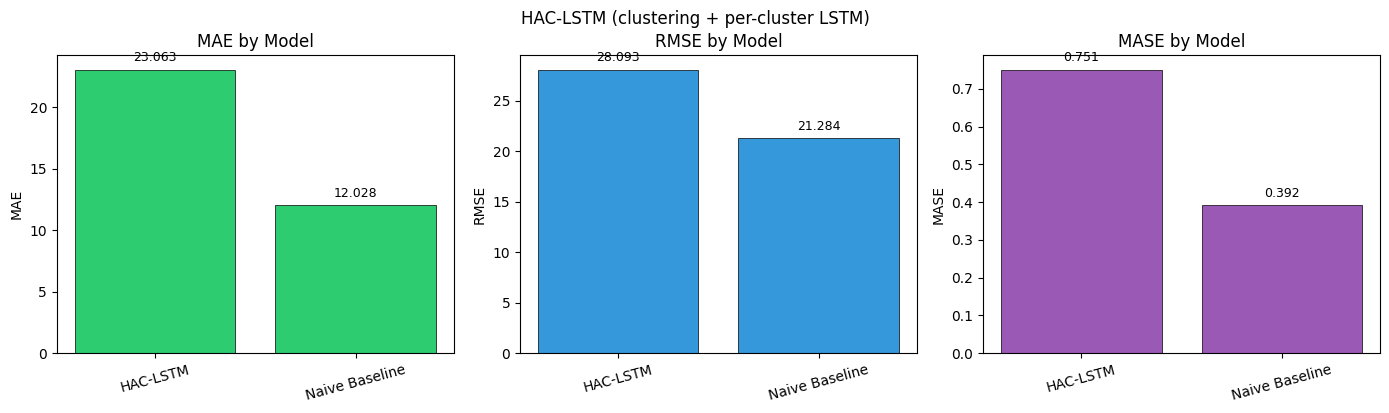

Improvement over Naive Baseline (%):


,Model,MAE_imp_%,RMSE_imp_%,MASE_imp_%
0,HAC-LSTM,-91.74,-31.99,-91.75


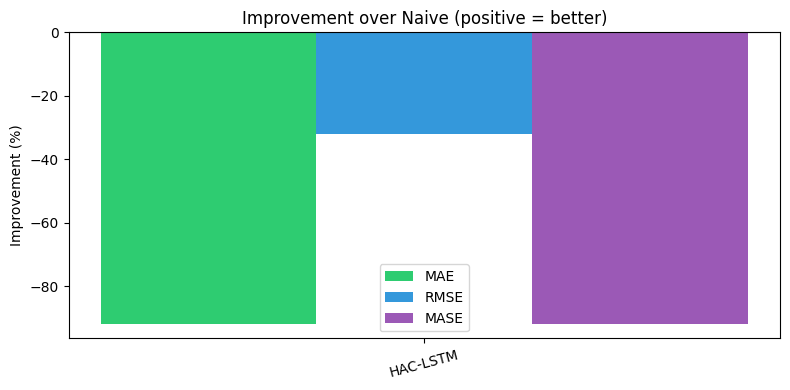

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['MAE', 'RMSE', 'MASE']
colors = ['#2ecc71', '#3498db', '#9b59b6']
for ax, metric, color in zip(axes, metrics, colors):
    vals = results_df[metric].values
    bars = ax.bar(results_df['Model'], vals, color=color, edgecolor='black', linewidth=0.5)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Model')
    ax.tick_params(axis='x', rotation=15)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02 * max(vals), f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.suptitle('HAC-LSTM (clustering + per-cluster LSTM)', y=1.02, fontsize=12)
plt.show()

naive_mae = results_df[results_df['Model'] == 'Naive Baseline']['MAE'].values[0]
naive_rmse = results_df[results_df['Model'] == 'Naive Baseline']['RMSE'].values[0]
naive_mase = results_df[results_df['Model'] == 'Naive Baseline']['MASE'].values[0]
improvement = results_df[results_df['Model'] != 'Naive Baseline'].copy()
improvement['MAE_imp_%'] = (1 - improvement['MAE'] / naive_mae) * 100
improvement['RMSE_imp_%'] = (1 - improvement['RMSE'] / naive_rmse) * 100
improvement['MASE_imp_%'] = (1 - improvement['MASE'] / naive_mase) * 100
print('Improvement over Naive Baseline (%):')
display(improvement[['Model', 'MAE_imp_%', 'RMSE_imp_%', 'MASE_imp_%']].round(2))
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(improvement))
w = 0.25
ax.bar(x - w, improvement['MAE_imp_%'], w, label='MAE', color='#2ecc71')
ax.bar(x, improvement['RMSE_imp_%'], w, label='RMSE', color='#3498db')
ax.bar(x + w, improvement['MASE_imp_%'], w, label='MASE', color='#9b59b6')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(improvement['Model'], rotation=15)
ax.set_ylabel('Improvement (%)')
ax.legend()
ax.set_title('Improvement over Naive (positive = better)')
plt.tight_layout()
plt.show()


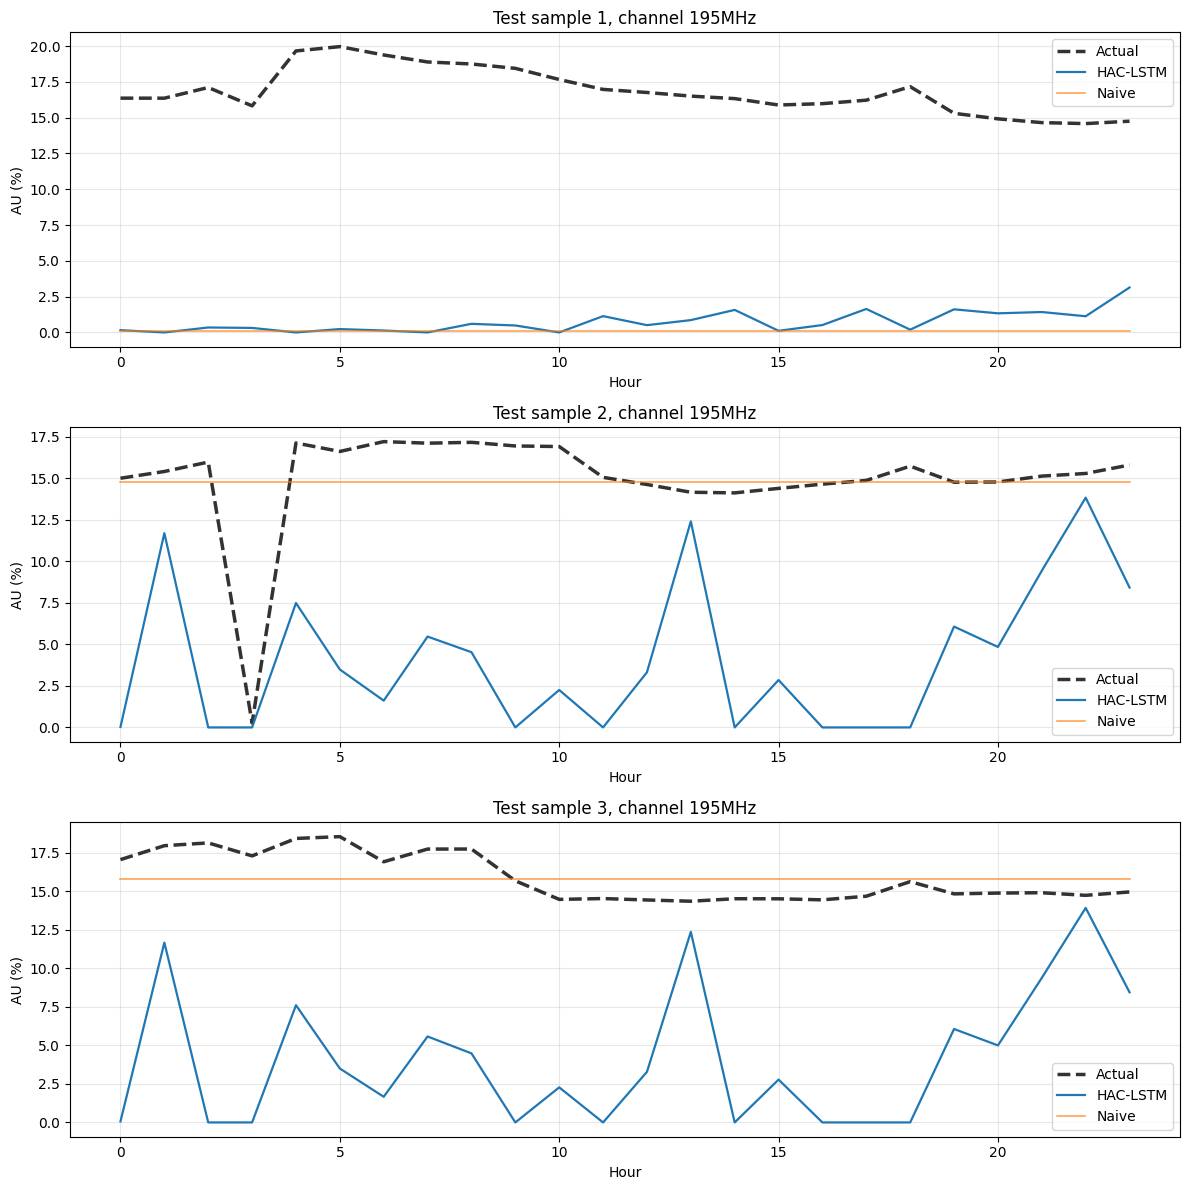

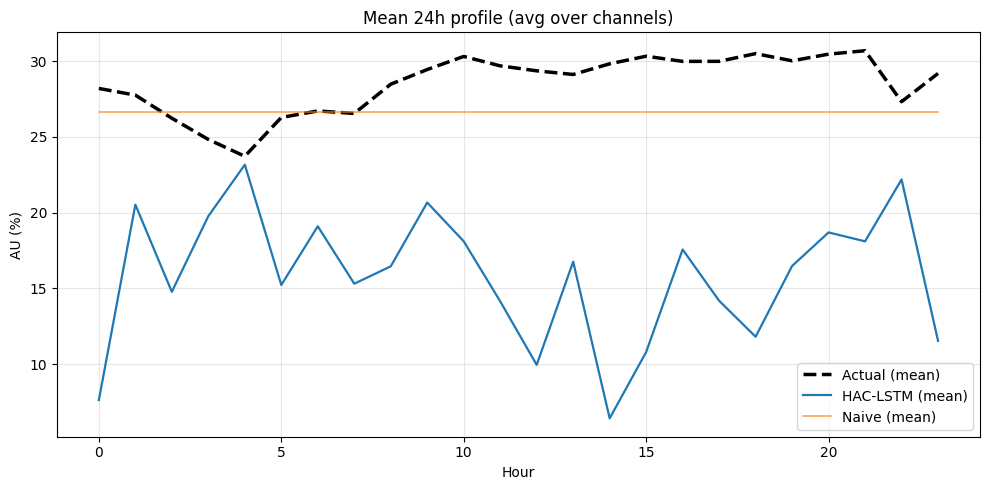

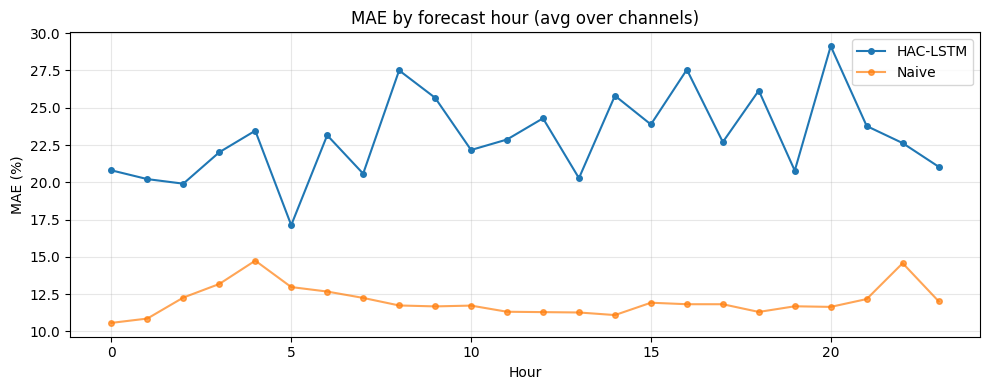

In [35]:
hours = np.arange(FORECAST_HORIZON)
ch_show = 0
n_show = min(3, len(y_test))
fig, axes = plt.subplots(n_show, 1, figsize=(12, 4*n_show))
if n_show == 1: axes = [axes]
for i in range(n_show):
    ax = axes[i]
    ax.plot(hours, y_test[i, :, ch_show], 'k--', linewidth=2.5, label='Actual', alpha=0.8)
    ax.plot(hours, y_pred_hac[i, :, ch_show], '-', linewidth=1.6, label='HAC-LSTM')
    ax.plot(hours, y_pred_naive[i, :, ch_show], '-', linewidth=1.2, label='Naive', alpha=0.7)
    ax.set_title(f'Test sample {i+1}, channel {band_cols[ch_show]}')
    ax.set_xlabel('Hour')
    ax.set_ylabel('AU (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hours, y_test.mean(axis=0).mean(axis=1), 'k--', linewidth=2.5, label='Actual (mean)')
ax.plot(hours, y_pred_hac.mean(axis=0).mean(axis=1), '-', linewidth=1.6, label='HAC-LSTM (mean)')
ax.plot(hours, y_pred_naive.mean(axis=0).mean(axis=1), '-', linewidth=1.2, label='Naive (mean)', alpha=0.7)
ax.set_title('Mean 24h profile (avg over channels)')
ax.set_xlabel('Hour')
ax.set_ylabel('AU (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

mae_per_hour = np.abs(y_test - y_pred_hac).mean(axis=(0, 2))
mae_per_hour_n = np.abs(y_test - y_pred_naive).mean(axis=(0, 2))
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hours, mae_per_hour, '-o', label='HAC-LSTM', markersize=4)
ax.plot(hours, mae_per_hour_n, '-o', label='Naive', markersize=4, alpha=0.7)
ax.set_title('MAE by forecast hour (avg over channels)')
ax.set_xlabel('Hour')
ax.set_ylabel('MAE (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


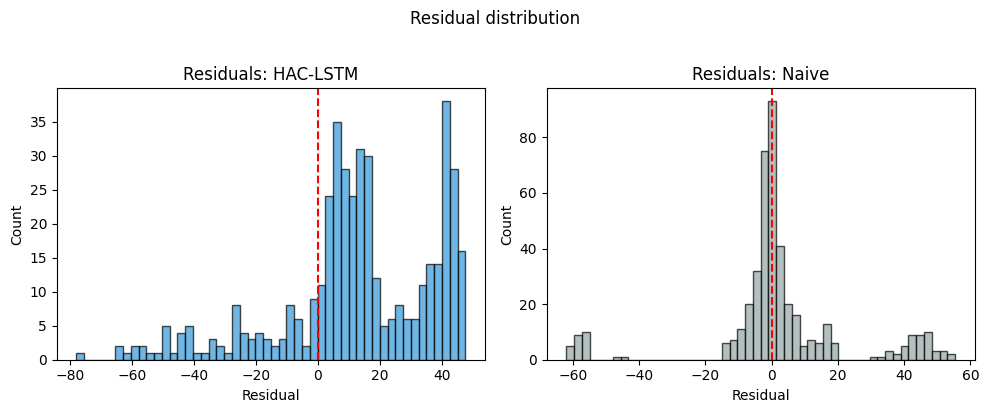

Residual mean (bias): HAC-LSTM = 12.7290, Naive = 1.8747
Residual std:         HAC-LSTM = 25.0438, Naive = 21.2008

Best model: HAC-LSTM (MAE=23.0629, RMSE=28.0931, MASE=0.7511). Improvement over Naive: MAE -91.7%.


In [36]:
residuals_h = (y_test - y_pred_hac).flatten()
residuals_naive = (y_test - y_pred_naive).flatten()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(residuals_h, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Count')
axes[0].set_title('Residuals: HAC-LSTM')
axes[1].hist(residuals_naive, bins=50, color='#95a5a6', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residuals: Naive')
plt.suptitle('Residual distribution', y=1.02)
plt.tight_layout()
plt.show()
print(f'Residual mean (bias): HAC-LSTM = {residuals_h.mean():.4f}, Naive = {residuals_naive.mean():.4f}')
print(f'Residual std:         HAC-LSTM = {residuals_h.std():.4f}, Naive = {residuals_naive.std():.4f}')

best_row = results_df[results_df['Model'] == 'HAC-LSTM'].iloc[0]
imp_mae = (1 - best_row['MAE'] / naive_mae) * 100
print(f"\nBest model: HAC-LSTM (MAE={best_row['MAE']:.4f}, RMSE={best_row['RMSE']:.4f}, MASE={best_row['MASE']:.4f}). Improvement over Naive: MAE {imp_mae:+.1f}%.")


### Key insights

- **Paper (CCNC 2021):** SRCC-based HAC (complete linkage) clusters correlated series; one LSTM per cluster avoids uncorrelated series degrading accuracy; low-pass filter preprocessing reduces high-frequency noise.
- **Per-cluster LSTM:** Each cluster's channels form (72, size_c) → (24, size_c); predictions are reassembled to (24, N).
- **Improvement over Naive:** Positive % means HAC-LSTM beats the last-value baseline.
